<a href="https://colab.research.google.com/drive/1i9uVbsz-ZFIfRQg-fv8ft1_q8sLWY_Jp?authuser=1"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 10 - Convolutional Neural Network, CNN - Homework by Łukasz Grzegrzółka

### Original notebook author: Szymon Nowakowski


# Presentation on Convolutional Layers
--------------------

We shall start off by going through a [short presentation on convolusional layers](https://github.com/SzymonNowakowski/Machine-Learning-2025/blob/master/convolutional_layers.pdf). It is best to first download it and then go through it in a slide-show layout.

# Reading MNIST Dataset
----------------------------------

In [ ]:
import torch
import torchvision
from matplotlib import pyplot

transform = torchvision.transforms.Compose(
    [ torchvision.transforms.ToTensor(), #Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]
      torchvision.transforms.Normalize((0.1307), (0.3081))])

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=transform)

trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=2048,
                                          shuffle=True)   #we do shuffle it to give more randomizations to training epochs

testset = torchvision.datasets.MNIST(root='./data',
                                     train=False,
                                     download=True,
                                     transform=transform)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=1,
                                         shuffle=False)

# Tensor Sizes
-------------------

Recall:
- Batched labels are of order one. The first (and only) index is a sample index within a batch.
- Image batches have order 4. The first order is a batch order, but a second order has dimensionality of 1 and thus it can be indexed by 0 only.
  - This index represents a Channel number inserted here by `ToTensor()` transformation, always 0.
  - This singleton order should be retained because we want to use convolutional layers, which explicitly require this order. For RGB images we have 3 channels, for B&W images we have only one channel.


# CNN Definition
-----------------



## Task

Your job now is to code the definition of the LeNet5 neural network. You can find the definition [here](https://en.wikipedia.org/wiki/LeNet#/media/File:Comparison_image_neural_networks.svg).


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.relu = torch.nn.ReLU()
        self.flatten = torch.nn.Flatten()
        self.avgpool = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.conv3 = torch.nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5)

        self.linear1 = torch.nn.Linear(120, 84)
        self.linear2 = torch.nn.Linear(84, 10)

        self.dropout = torch.nn.Dropout(0.05)

    def forward(self, x):               #B x 1   x 28 x 28
        x = F.relu(self.conv1(x))       #B x 6   x 28 x 28
        x = self.avgpool(x)             #B x 6   x 14 x 14
        x = F.relu(self.conv2(x))       #B x 16  x 10 x 10
        x = self.avgpool(x)             #B x 16  x  5 x  5
        x = F.relu(self.conv3(x))       #B x 120 x  1 x  1

        x = self.flatten(x)             #B x 120
        x = F.relu(self.linear1(x))     #B x 84
        x = self.linear2(x)             #B x 10
        x = self.dropout(x)

        return x

# Training Loop
----------------------

In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

net = LeNet5().to(device)
optimizer = torch.optim.Adam(net.parameters(), 0.001)   #initial and fixed learning rate of 0.001.

net.train()    #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing traning
for epoch in range(16):  #  an epoch is a training run through the whole data set

    for batch, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        batch_inputs = batch_inputs.to(device)  #explicitly moving the data to the target device
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        batch_outputs = net(batch_inputs)   #this line calls the forward(self, x) method of the LeNet5 object. Please note,
                                            # the nonlinear activation after the last layer is NOT applied
        loss = torch.nn.functional.cross_entropy(batch_outputs, batch_labels, reduction = "mean") #instead, nonlinear softmax is applied internally in THIS loss function
        print("epoch:", epoch, "batch:", batch, "current batch loss:", loss.item())
        loss.backward()       #this computes gradients as we have seen in previous workshops
        optimizer.step()     #but this line in fact updates our neural network.
                                ####You can experiment - comment this line and check, that the loss DOE

Working on cuda
epoch: 0 batch: 0 current batch loss: 2.30765962600708
epoch: 0 batch: 1 current batch loss: 2.2993645668029785
epoch: 0 batch: 2 current batch loss: 2.2906627655029297
epoch: 0 batch: 3 current batch loss: 2.282832145690918
epoch: 0 batch: 4 current batch loss: 2.268571376800537
epoch: 0 batch: 5 current batch loss: 2.256960391998291
epoch: 0 batch: 6 current batch loss: 2.2403006553649902
epoch: 0 batch: 7 current batch loss: 2.215489625930786
epoch: 0 batch: 8 current batch loss: 2.1890692710876465
epoch: 0 batch: 9 current batch loss: 2.1607491970062256
epoch: 0 batch: 10 current batch loss: 2.1275079250335693
epoch: 0 batch: 11 current batch loss: 2.074720859527588
epoch: 0 batch: 12 current batch loss: 2.0145697593688965
epoch: 0 batch: 13 current batch loss: 1.9953566789627075
epoch: 0 batch: 14 current batch loss: 1.9265519380569458
epoch: 0 batch: 15 current batch loss: 1.8536566495895386
epoch: 0 batch: 16 current batch loss: 1.7698777914047241
epoch: 0 batch:

# Testing
----------------------

In [ ]:
good = 0
wrong = 0

net.eval()              #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing evaluation
with torch.no_grad():   #it prevents that the net learns during evalution. The gradients are not computed, so this makes it faster, too
    for batch, data in enumerate(testloader): #batches in test are of size 1
        datapoint, label = data

        prediction = net(datapoint.to(device))                  #prediction has values representing the "prevalence" of the corresponding class
        classification = torch.argmax(prediction)    #the class is the index of maximal "prevalence"

        if classification.item() == label.item():
            good += 1
        else:
            wrong += 1

print("accuracy = ", good/(good+wrong))

accuracy =  0.9823


# Understanding Kernel Size, Stride and Padding

## Task: Designing a Convolutional Neural Network with a Target Receptive Field

Design a convolutional neural network using only 3×3 or 5×5 convolutional layers and 2×2 max-pooling layers without overlap (i.e., with stride 2). Use no padding in any layer. Insert a max-pooling layer after every two or three convolutional layers.

Your goal is to construct an architecture such that the receptive field of each output neuron is approximately 60×60 pixels.

Compute the receptive field size of the final output layer.

Compute the effective stride of the output layer with respect to the input.

Assuming an input image size of 400×400, determine the spatial size of the output feature map.

Q: Where would you locate ReLU layers?
Q: What if we can't match the desired input size with our architecture?
Q: Discuss what possible impact padding can have on the network performance.



# **Homework Assignment – Adversarial Examples**

In this assignment, you will explore how small (invisible to humans) changes to real digits can _fool_ the CNN into misclassifying them, even though the changes are imperceptible to humans.



## Task 1 – CNN Dreams: Last Homework Assignment Revisited

Re-run the input optimization process (for NN dreams) from the previous MLP-class homework assignment, but this time using the **LeNet-5 CNN model** we trained in this class.


1. Starting from ten random noise images, optimize the input so that each image is classified with high confidence as one of the digits 0 through 9.
2. Include an **L2 penalty** on the input to keep the images visually closer to realistic digits. Use a range of penalty strengths (e.g., $\lambda_{l2}$ = 0, and then 0.01 through 10.0).
3. Compare the generated images (with and without L2 penalty) to those generated by the MLP:
   - Are they more or less readable?
   - Do they resemble real MNIST digits more closely or less?
   - Why do you think that happens? Consider the CNN’s inductive biases and architectural properties.

Use `cross_entropy_loss + lambda_l2 * input.pow(2).mean()` as your objective.

Reuse your code: visualize confidence evolution during optimization and generate image grids and (optionally) animations showing how the inputs evolve.


## Task 2 – Adversarial Examples: Fooling LeNet-5

This is the core focus of the assignment.

Using a batch of **real MNIST digits** (e.g., nine examples per class), craft **adversarial examples** by adding subtle, trained noise to the input images. Your goal is to:

- **Keep the human-perceived digit the same** (e.g., a "7" should still look like a "7"),
- But **cause LeNet-5 to misclassify it** – as every other class different from the original, hence nine examples per class.

### Objective
For each image $x$ and its true label $y$, learn a perturbation $\delta$ such that:

- $\text{LeNet5}(x + \delta) = y_{\text{wrong}} $,
- and $ \|\delta\|_2 $ is as small as possible (penalize large perturbations), to keep $x + \delta$ *look* like $x$ for humans.

### Optimization
Use gradient-based optimization on $\delta$ (the noise), while keeping the network weights frozen. Your loss might look like:

```
loss = cross_entropy(model(x + delta), target_wrong_class) +
       lambda_l2 * delta.pow(2).mean()
```

Tune the $\lambda_{l2}$ to find the best range.

### Deliverables for the Second Task
- Select some best examples, showing the original digit and its (correct) classification and the perturbed digit (hopefully, still looking the same to humans) and how it gets misclassified. Show them side by side.
- Report:
  - Success rate of attacks (it doesn't need to be very formal),
  - Effect of $\lambda_{l2}$ on visibility of the noise and success of misclassification,
  - Example image grids and confidence plots.



## Deliverables for the Homework Assignment
- A Google Colab notebook with:
  - Complete implementation for both tasks.
  - Visualizations and animations (animations are optional but encouraged).
  - Clear written analysis of your findings.
- Upload the notebook and results to your GitHub repository for the course.
- Include a link to the notebook and video (if applicable) in the `README.md`.
- In the notebook, include “Open in Colab” badge so it can be launched directly.

## Task 1

### Function used for plotting the results of Task 1

In [ ]:
import matplotlib.pyplot as plt

def show_dreams(images, logits, step):
    """
    images: tensor (10, 1, 28, 28) - after detach().cpu()
    logits: tensor (10, 10) - net output, without softmax
    step: iteration number
    """
    probs = torch.nn.functional.softmax(logits, dim=1).cpu()  # probabilities
    preds = probs.argmax(dim=1)             # predicted digits

    fig, axes = plt.subplots(1, images.shape[0], figsize=(18, 2.5))
    fig.suptitle(f"Step {step}", fontsize=16)

    for i in range(images.shape[0]):
        axes[i].imshow(images[i, 0], cmap="gray")
        axes[i].axis("off")

        pred_digit = preds[i].item()
        confidence = probs[i, pred_digit].item() * 100

        axes[i].set_title(f"{pred_digit}\n{confidence:.1f}%", fontsize=10)

    plt.show()

### a) Version without additional $L_2$ penalty

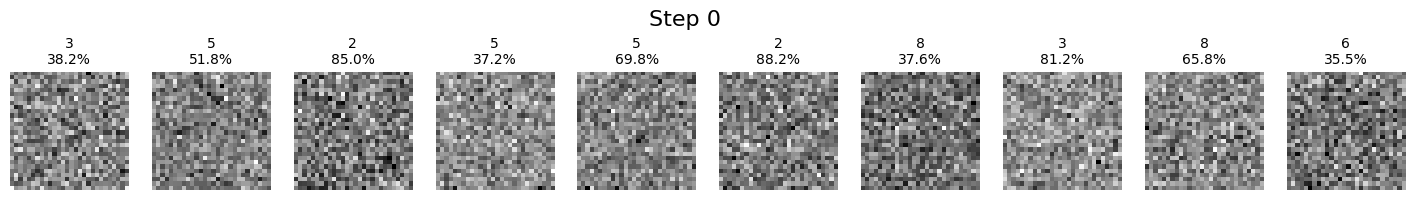

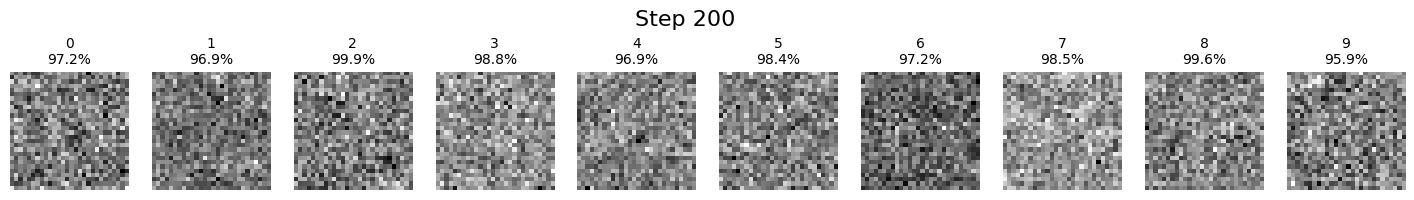

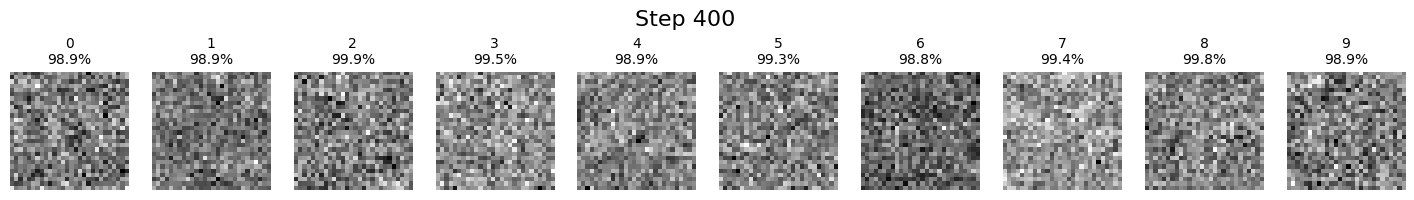

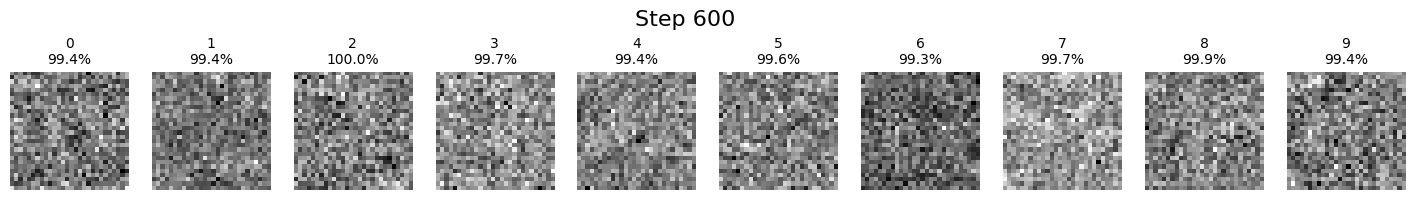

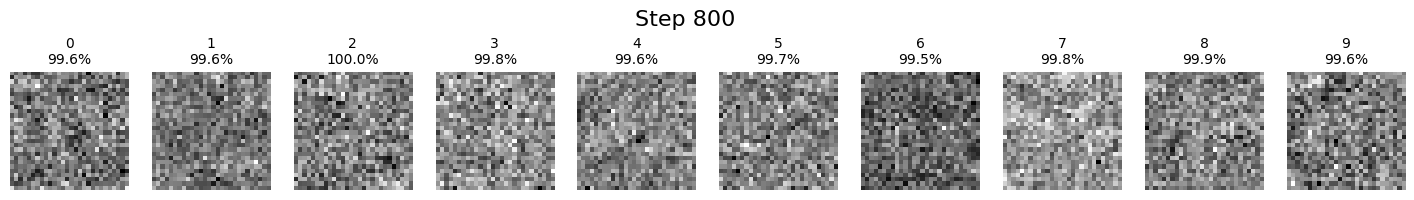

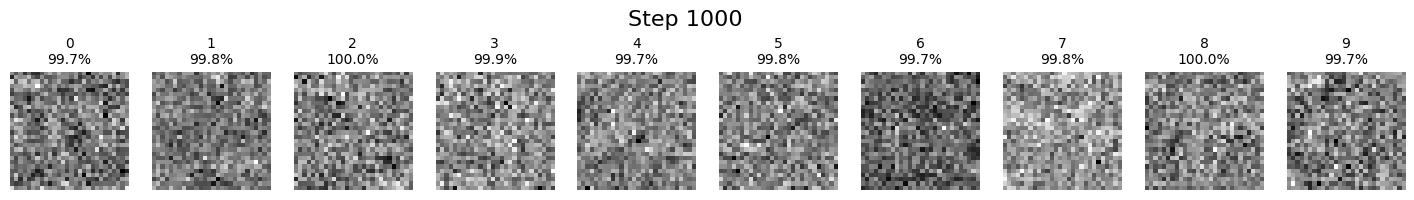

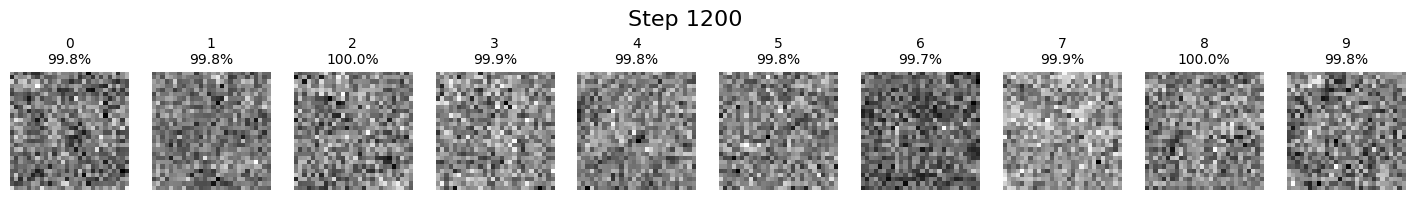

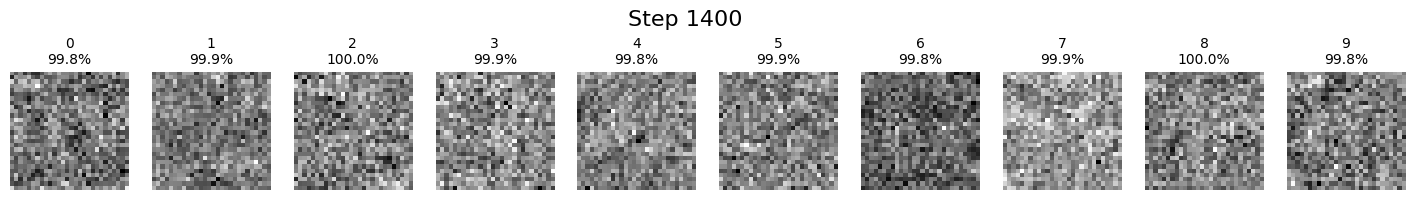

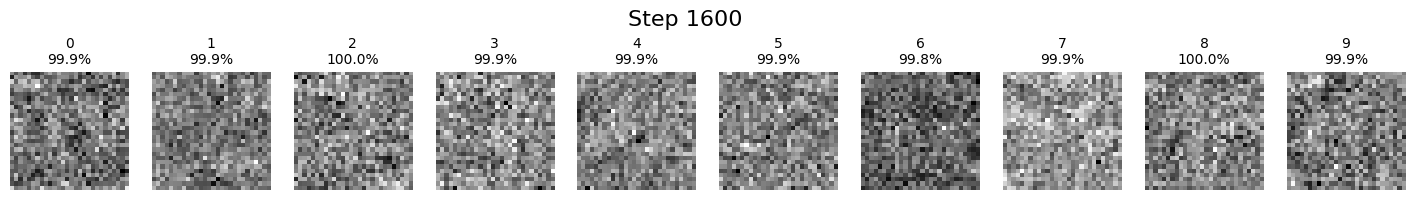

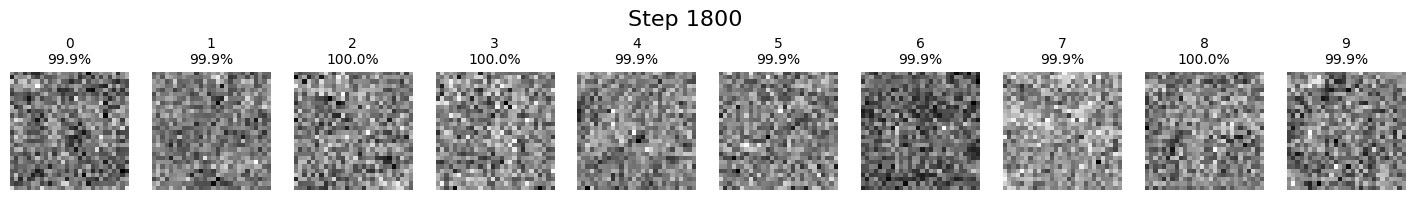

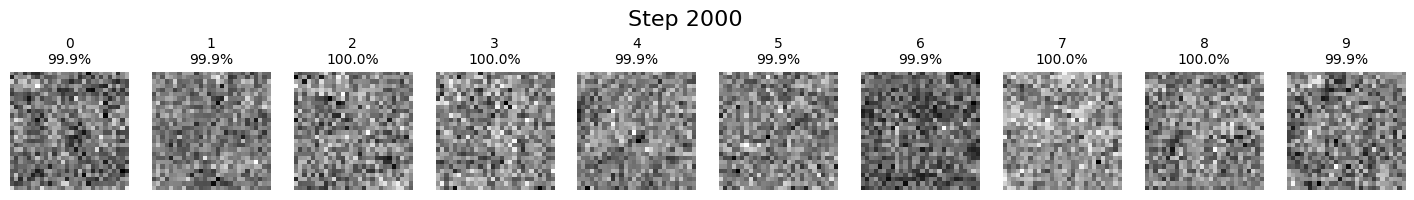

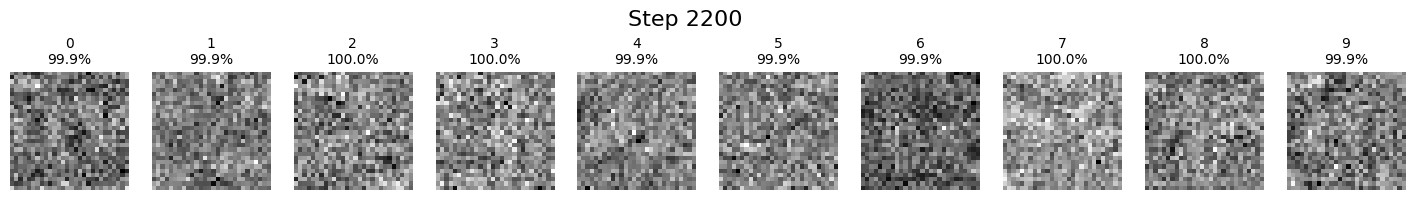

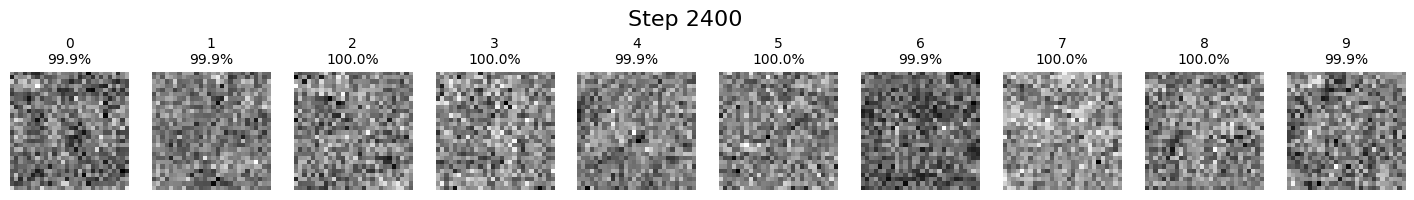

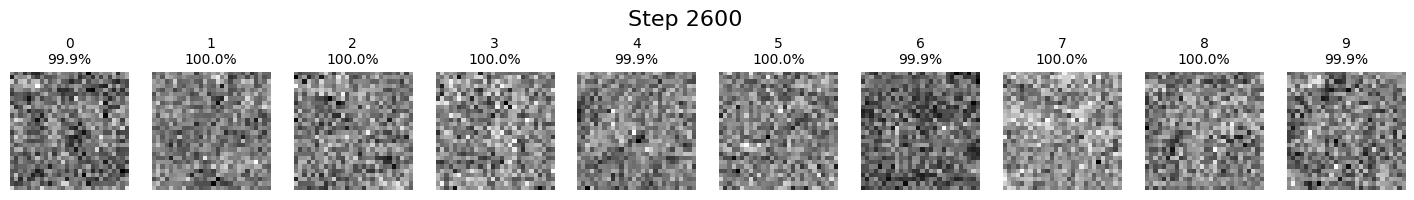

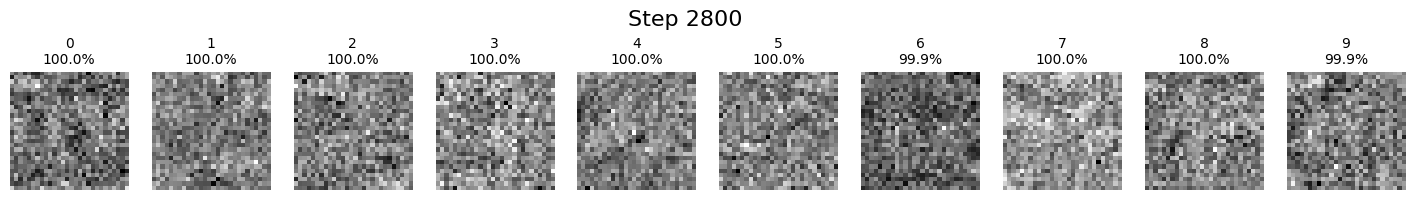

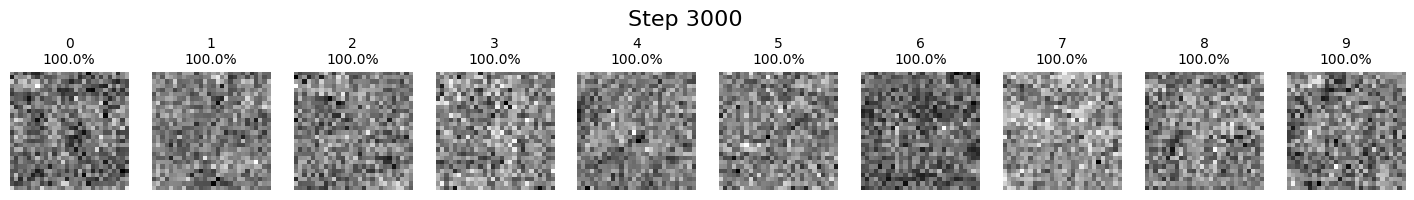

In [ ]:
# We do not want to change the parameters of the net, so we set it to eval() mode ang turn off 'requires_grad' parameters
net.eval()
for p in net.parameters():
    p.requires_grad = False

#We create 10 random noise images for the optimization process
dreams = torch.randn(10, 1, 28, 28, device=device, requires_grad=True)
targets = torch.arange(10, device=device)       #target labels

optimizer = torch.optim.Adam([dreams], lr=0.005)

evolution_task1a = []

for step in range(3001):
    optimizer.zero_grad()
    out = net(dreams)
    loss = torch.nn.functional.cross_entropy(out, targets)
    loss.backward()
    optimizer.step()

    if step % 200 == 0:
        plot_images = dreams.detach().cpu().clone()
        plot_logits = out.detach().cpu().clone()
        evolution_task1a.append((plot_images, plot_logits))

        show_dreams(plot_images, plot_logits, step)


W eksperymencie bez kary L2 zainicjowano dziesięć losowych obrazów i zoptymalizowano je tak, aby LeNet‑5 klasyfikował każdy z nich z bardzo wysoką pewnością jako kolejną cyfrę od 0 do 9; końcowy efekt to obrazy, które sieć rozpoznaje niemal ze 100% pewnością, podczas gdy dla człowieka nadal wyglądają głównie jak zaszumione pola pikseli. W porównaniu z wcześniejszymi wynikami uzyskanymi na MLP widać jednak istotną różnicę: wygenerowane przez CNN obrazy wykazują wyraźniejsze makrostruktury, takie jak lokalne krawędzie i zarysy, które sugerują pewną organizację przestrzenną, choć niekoniecznie przypominają czytelne, naturalne cyfry. To rozbieżność między wysoką pewnością modelu a niską czytelnością dla człowieka wynika z faktu, że optymalizacja znajduje wzorce silnie aktywujące filtry LeNet‑5; architektura konwolucyjna sprzyja tworzeniu lokalnych, „zorganizowanych” cech, stąd mniej losowy wygląd niż w MLP, ale bez dodatkowych ograniczeń (np. kary L2) te wzorce nie muszą być semantycznie zgodne z naturalnymi przykładami. Wynik sugeruje, że aby uzyskać bardziej realistyczne i czytelne obrazy, warto wprowadzić regularyzację lub ograniczenia normy perturbacji, które wymuszą kompromis między pewnością klasyfikacji a zredukowaniem losowego szumu, pozwalając zachować wygląd bardziej naturalny dla człowieka.

### Animation for Task 1a)

In [ ]:
from matplotlib import animation

def animate_task1_matplotlib(evolution, interval=400):
    """
    evolution: lista elementów (images, logits),
               images: (10, 1, 28, 28), logits: (10, 10)
    """
    fig, axes = plt.subplots(1, evolution[0][0].shape[0], figsize=(18, 2.5))

    def init():
        for ax in axes:
            ax.axis("off")
        return axes

    def update(frame_idx):
        images, logits = evolution[frame_idx]
        probs = torch.nn.functional.softmax(logits, dim=1).cpu()
        preds = probs.argmax(dim=1)

        fig.suptitle(f"Frame: {frame_idx}", fontsize=16)

        for i in range(images.shape[0]):
            axes[i].clear()
            axes[i].imshow(images[i, 0], cmap="gray")
            axes[i].axis("off")

            pred_digit = preds[i].item()
            confidence = probs[i, pred_digit].item() * 100
            axes[i].set_title(f"{pred_digit}\n{confidence:.1f}%", fontsize=10)

        return axes

    anim = animation.FuncAnimation(
        fig,
        update,
        init_func=init,
        frames=len(evolution),
        interval=interval,
        blit=False
    )
    plt.close()
    return anim


In [ ]:
from IPython.display import HTML
anim1a = animate_task1_matplotlib(evolution_task1a)
print("Animation for Task 1a) - without penalization")
HTML(anim1a.to_jshtml())


Animation for Task 1a) - without penalization


### b) Version including additional $L_2$ penalty

Experiment with lambda_l2 = 0.1


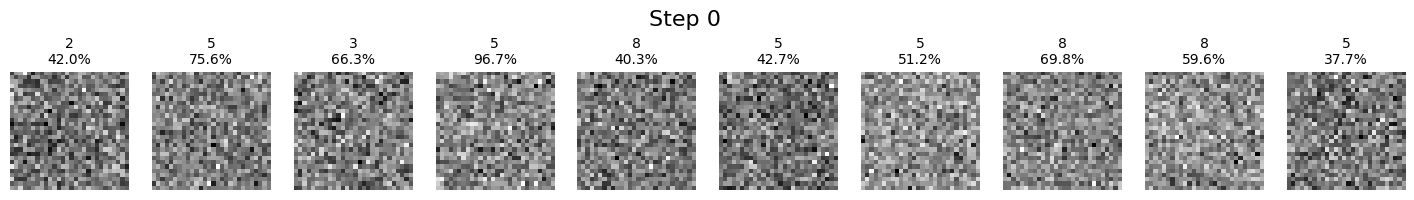

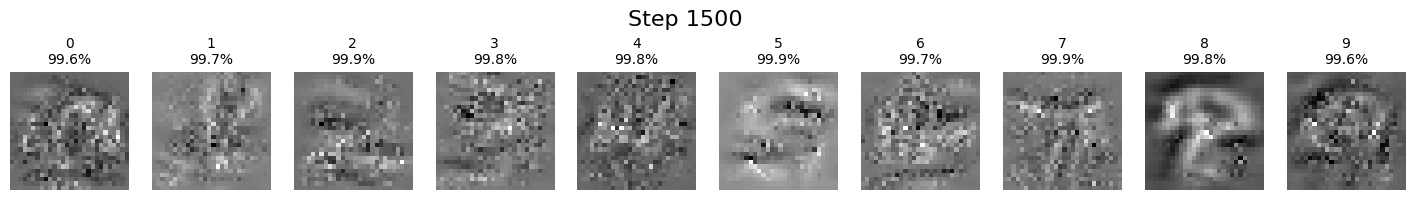

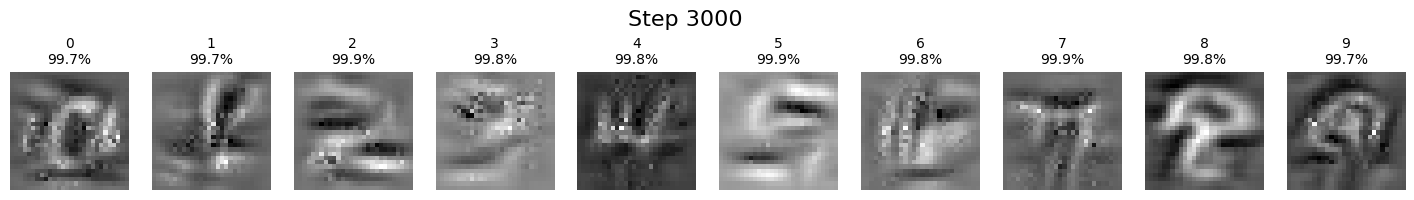

Experiment with lambda_l2 = 0.3981


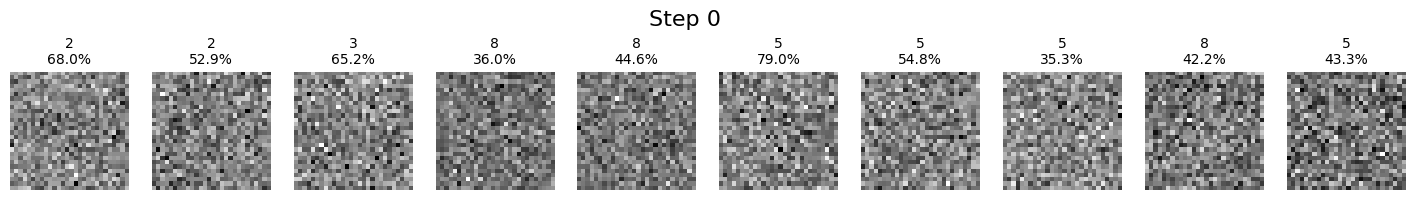

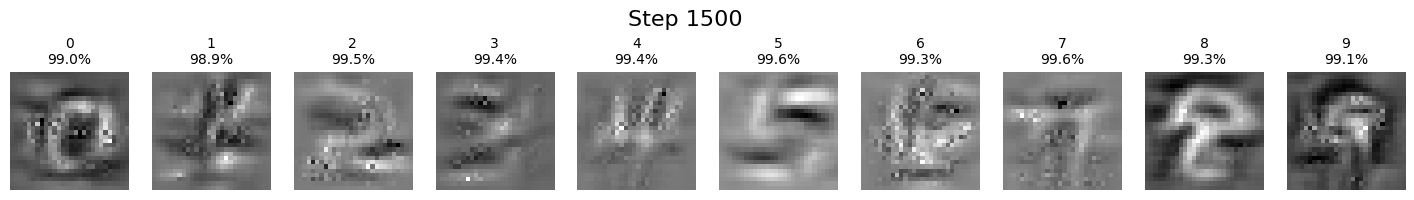

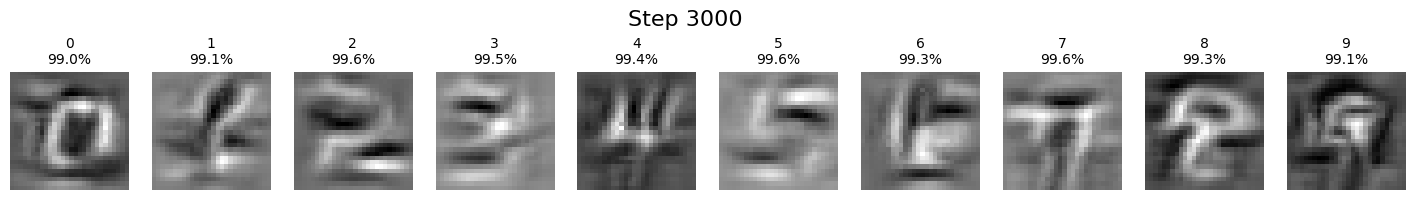

Experiment with lambda_l2 = 1.585


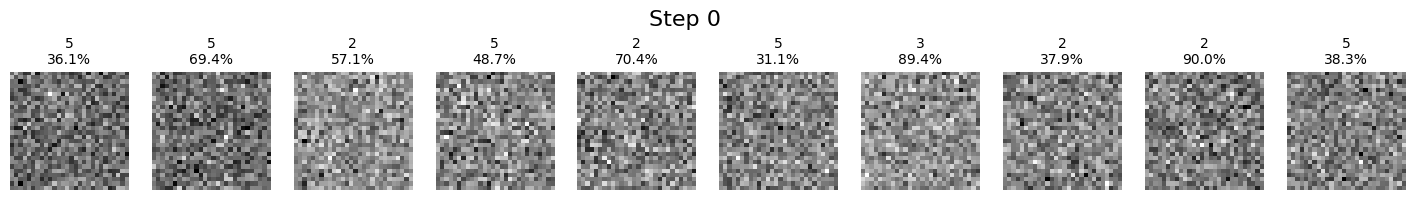

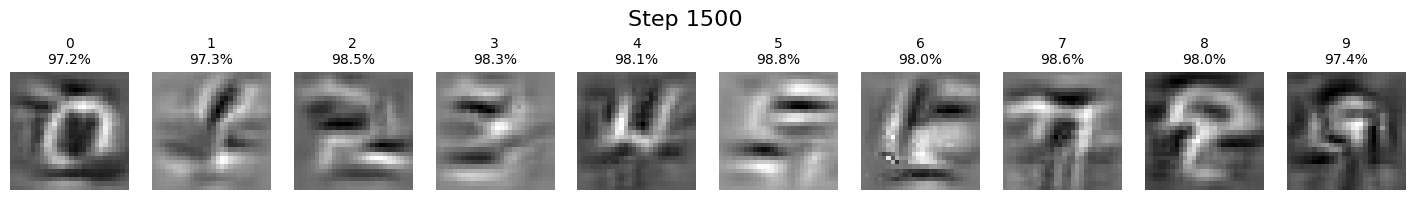

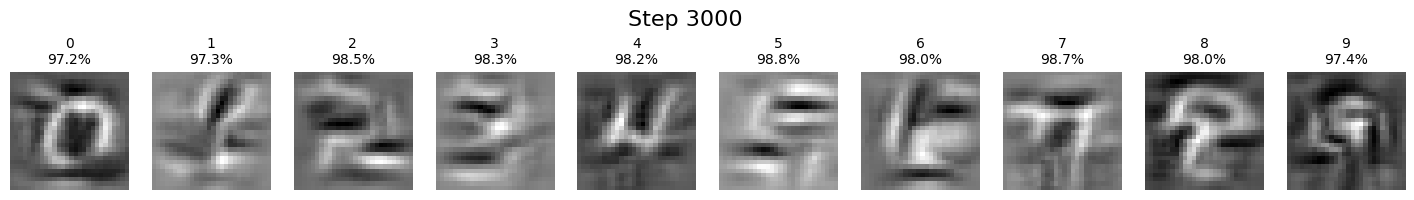

Experiment with lambda_l2 = 6.31


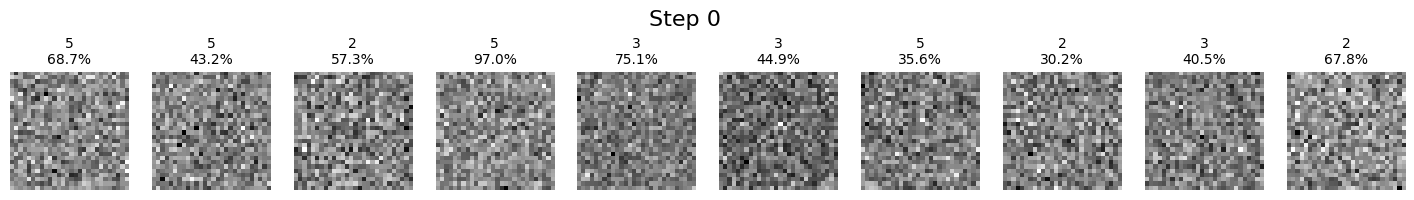

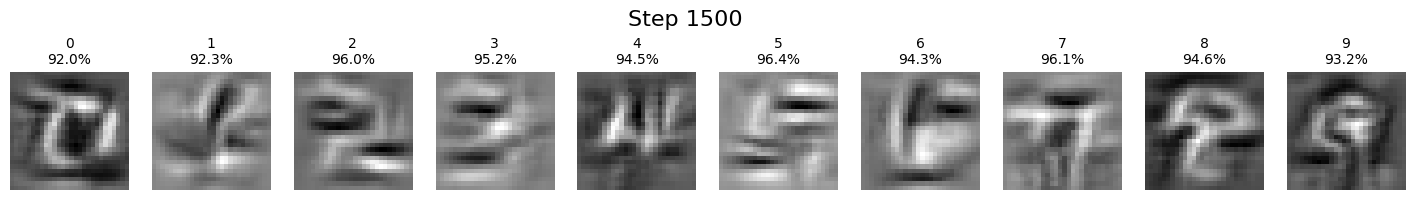

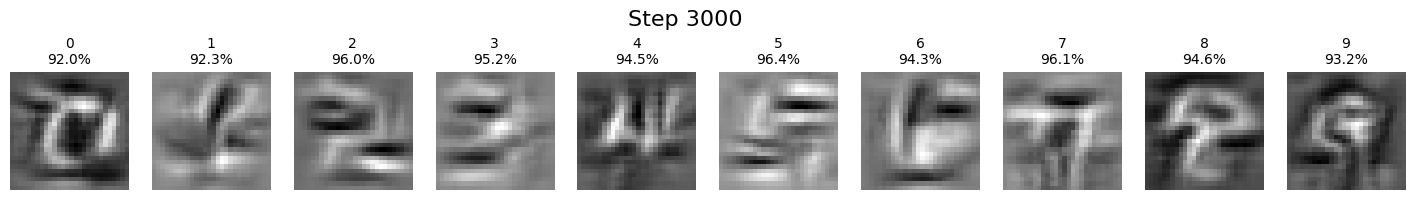

Experiment with lambda_l2 = 25.12


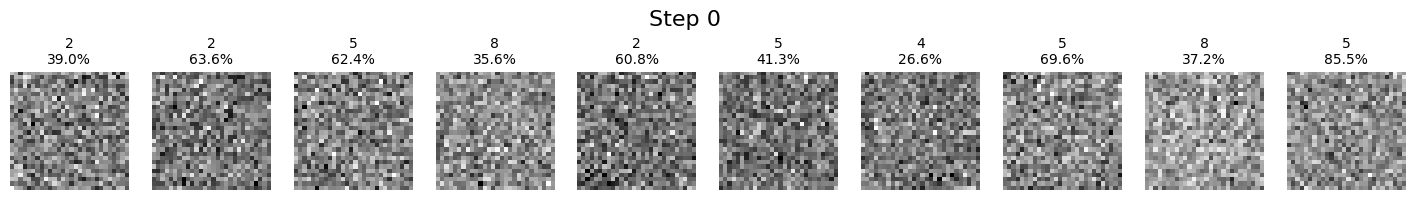

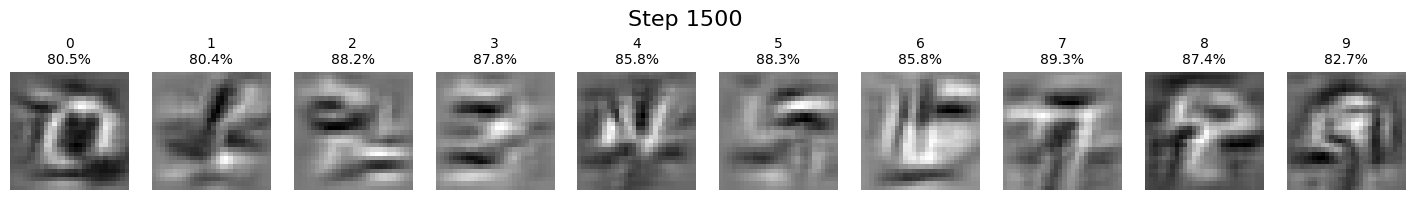

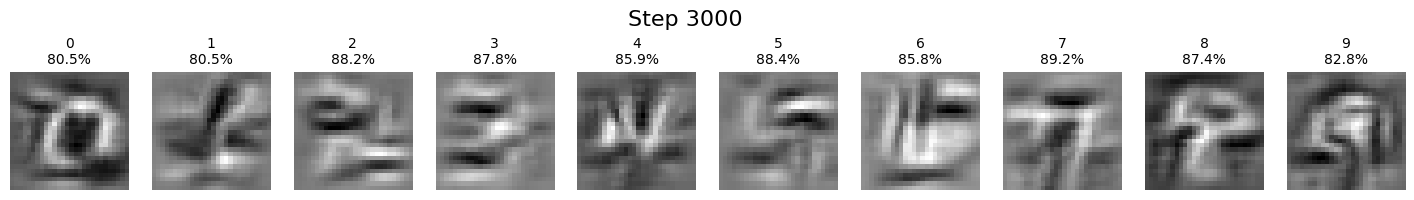

Experiment with lambda_l2 = 100.0


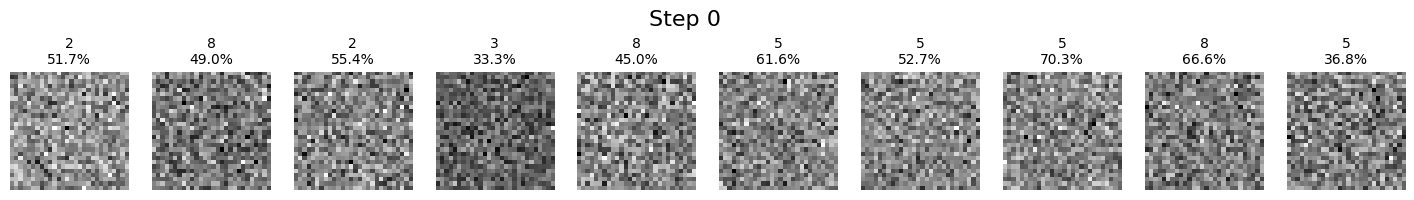

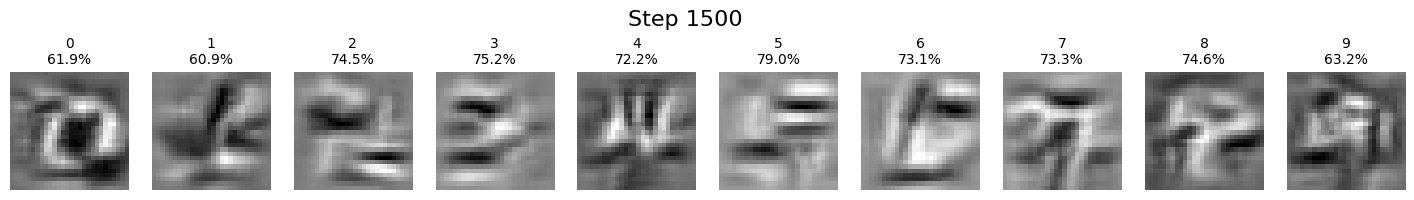

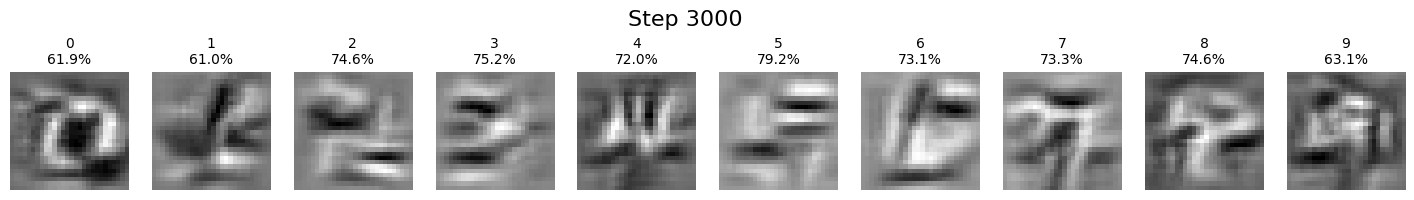

In [ ]:
import numpy as np
#lambda_l2 * dreamed_input_batch.pow(2).mean()

def task1_witl_l2_penalty(lambda_l2, n_steps=3001, plot_frames=True, plot_interval=1500, animate=True, animate_interval=100):
    # We do not want to change the parameters of the net, so we set it to eval() mode ang turn off 'requires_grad' parameters
    net.eval()
    for p in net.parameters():
        p.requires_grad = False

    #We create 10 random noise images for the optimization process
    dreams = torch.randn(10, 1, 28, 28, device=device, requires_grad=True)
    targets = torch.arange(10, device=device)       #target labels

    optimizer = torch.optim.Adam([dreams], lr=0.01)

    evolution = []

    print(rf"Experiment with lambda_l2 = {lambda_l2:.4}")
    for step in range(n_steps):
        optimizer.zero_grad()
        out = net(dreams)
        loss = torch.nn.functional.cross_entropy(out, targets) + lambda_l2 * dreams.pow(2).mean()
        loss.backward()
        optimizer.step()

        if plot_frames and step % plot_interval == 0:
            plot_images = dreams.detach().cpu().clone()
            plot_logits = out.detach().cpu().clone()
            evolution.append((plot_images, plot_logits))
            show_dreams(plot_images, plot_logits, step)

        if animate and step % animate_interval == 0:
            plot_images = dreams.detach().cpu().clone()
            plot_logits = out.detach().cpu().clone()
            evolution.append((plot_images, plot_logits))

    return evolution

penalties = np.geomspace(0.1, 100, 6)
for penalty in penalties:
    task1_witl_l2_penalty(penalty, animate=False)


Wprowadzenie kary $L_2$ całkowicie zmienia charakter optymalizowanych obrazów. Nawet przy najmniejszej zastosowanej wartości $\lambda = 0.1$ ilość przypadkowego szumu wyraźnie maleje, a na obrazach zaczynają pojawiać się stabilne, makroskopowe struktury, które w wielu przypadkach przypominają już kształty znane z rzeczywistych cyfr MNIST. Efekt ten jest szczególnie widoczny dla cyfr takich jak 2, 3, 4, 5 czy 8, gdzie po kilku tysiącach kroków optymalizacji można dostrzec charakterystyczne zarysy, które, zwłaszcza gdy wiemy, jakiej cyfry się spodziewać, są dla człowieka rozpoznawalne. Wraz ze wzrostem wartości $\lambda$ do zakresu około 1–10 obrazy stają się jeszcze bardziej uporządkowane: szum jest wygładzony, a struktury wyraźniejsze, co sprawia, że generowane wzorce zaczynają przypominać uproszczone, ale czytelne wersje cyfr. Jednocześnie sieć nadal klasyfikuje je z bardzo wysoką pewnością, co oznacza, że kara $L_2$ skutecznie ogranicza niepotrzebne fluktuacje pikseli, nie zaburzając przy tym zdolności modelu do wydobywania cech istotnych dla klasyfikacji.

Dopiero przy wartościach $\lambda$ przekraczających 10 zaczyna być widoczne, że penalizacja staje się zbyt silna: obrazy są wprawdzie bardzo gładkie i pozbawione szumu, ale jednocześnie tracą część struktur, które sieć wykorzystuje do rozpoznawania klas. W rezultacie model nadal wskazuje poprawne etykiety, lecz robi to z wyraźnie mniejszą pewnością. Oznacza to, że zbyt duża regularizacja ogranicza swobodę optymalizacji do tego stopnia, że sieć nie jest w stanie w pełni „wyrysować” charakterystycznych cech danej cyfry. Całość eksperymentu pokazuje więc, że umiarkowana kara $L_2$ pełni kluczową rolę w równoważeniu dwóch celów: zachowania czytelności obrazu oraz utrzymania wysokiej pewności klasyfikacji, a zakres $\lambda \approx 1 - 10$ stanowi w tym przypadku najbardziej efektywny kompromis.

### Animation for Task 1b)

In [ ]:
from IPython.display import HTML

penalty = 6.0

evolution_task1b = task1_witl_l2_penalty(lambda_l2=penalty, plot_frames=False, animate=True)
anim1b = animate_task1_matplotlib(evolution_task1b)
HTML(anim1b.to_jshtml())


Experiment with lambda_l2 = 6.0


## Task 2

### Function used for plotting the results of Task 2

In [ ]:
import matplotlib.pyplot as plt

def show_dreams(images, logits, step):
    """
    images: tensor (images.size(0), 1, 28, 28) - after detach().cpu()
    logits: tensor (images.size(0), 10) - net output, without softmax
    step: iteration number
    """
    probs = torch.nn.functional.softmax(logits, dim=1).cpu()  # probabilities
    preds = probs.argmax(dim=1)             # predicted digits

    fig, axes = plt.subplots(1, images.shape[0], figsize=(18, 2.5))
    fig.suptitle(f"Step {step}", fontsize=16)

    #for the case images.shape[0] = 1
    if images.shape[0] == 1:
        axes = [axes]

    for i in range(images.shape[0]):
        axes[i].imshow(images[i, 0], cmap="gray")
        axes[i].axis("off")

        pred_digit = preds[i].item()
        confidence = probs[i, pred_digit].item() * 100

        axes[i].set_title(f"{pred_digit}\n{confidence:.1f}%", fontsize=10)

    plt.show()

Original label: 2, L2 penalty: 0.0001


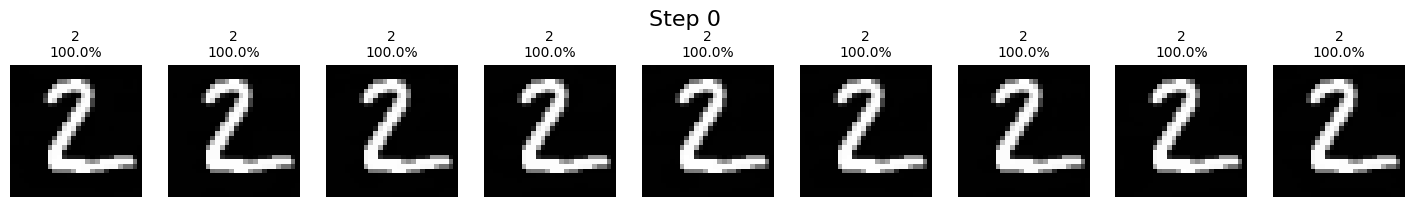

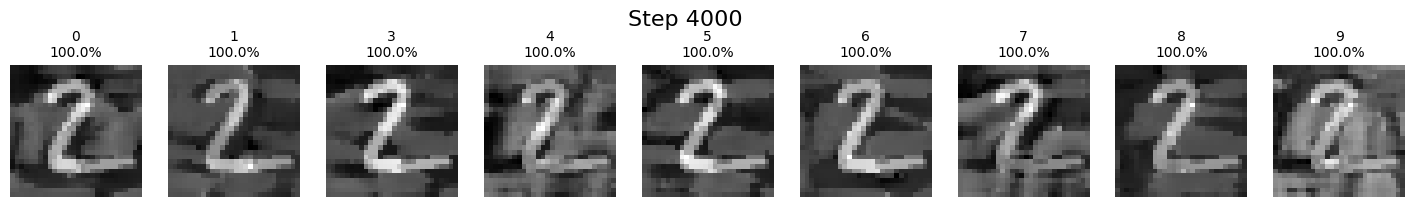

Original label: 2, L2 penalty: 0.0004642


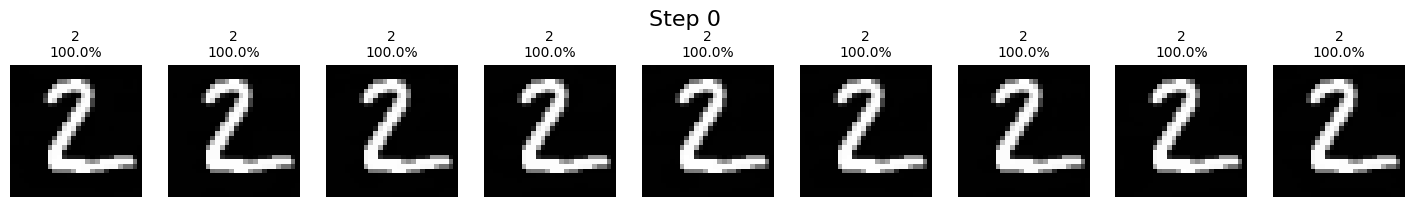

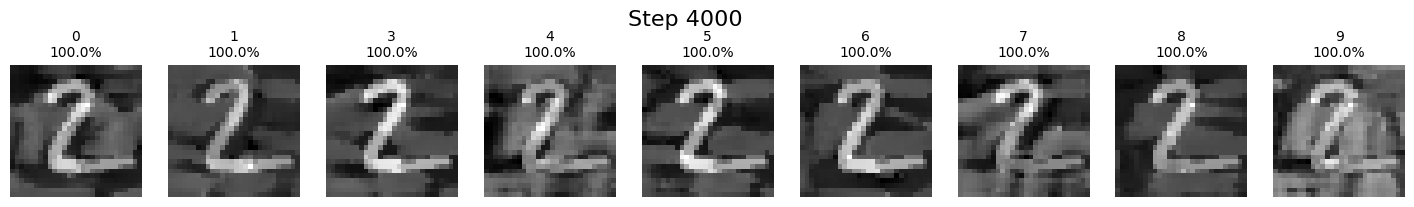

Original label: 2, L2 penalty: 0.002154


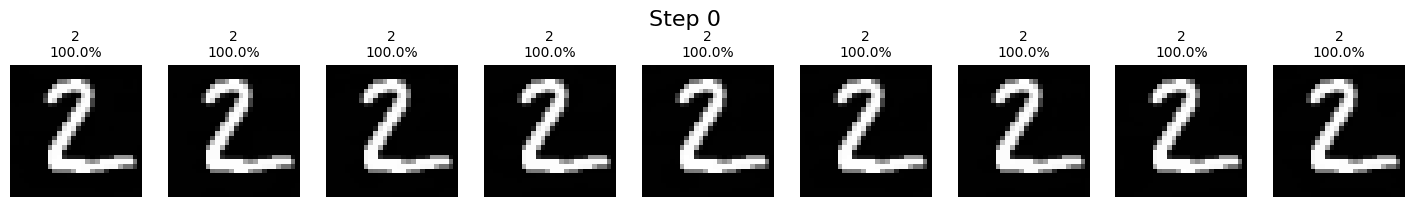

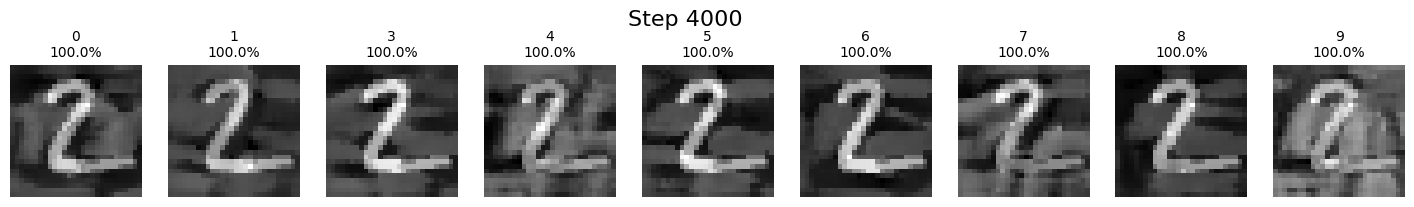

Original label: 2, L2 penalty: 0.01


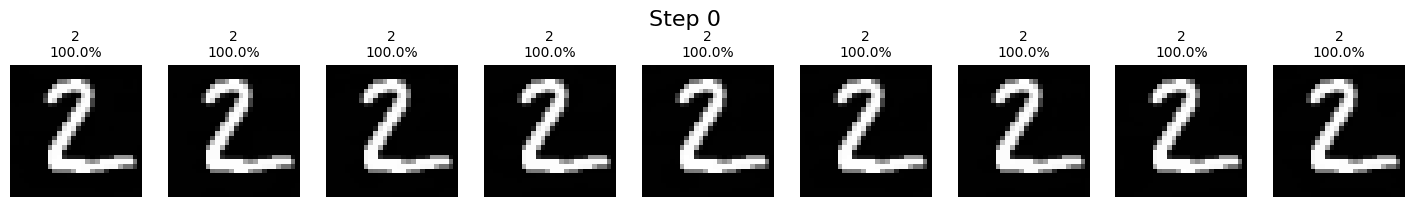

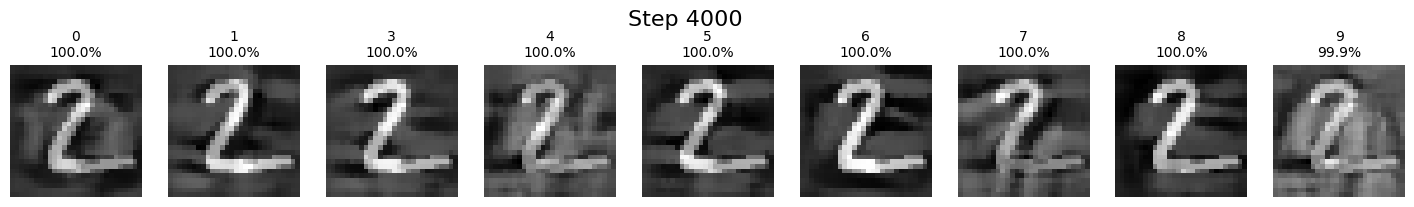

Original label: 2, L2 penalty: 0.04642


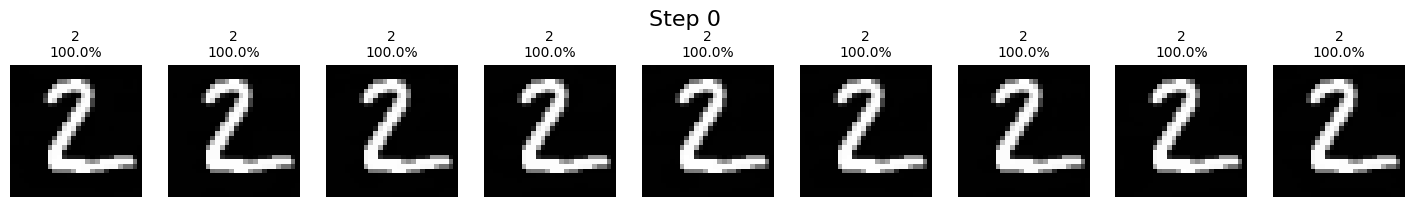

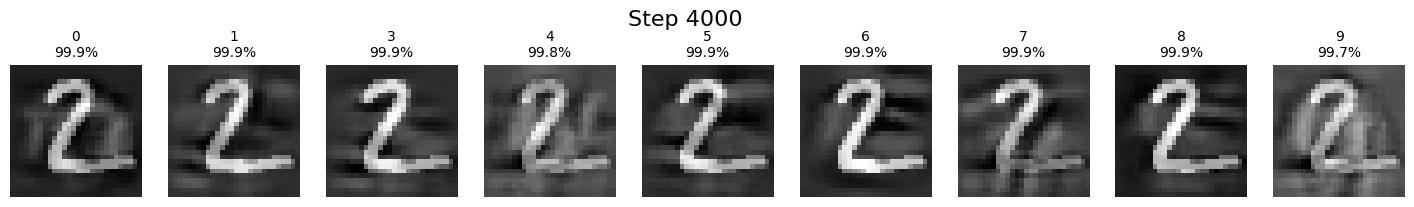

Original label: 2, L2 penalty: 0.2154


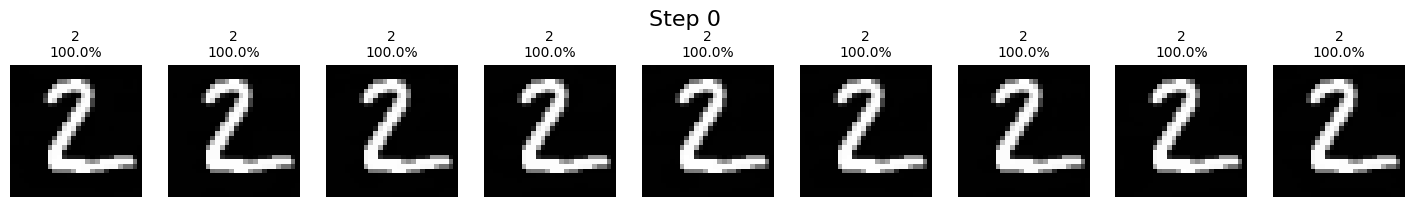

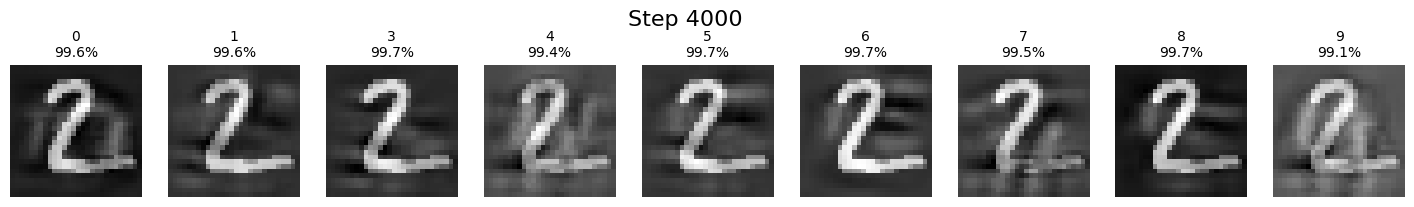

Original label: 2, L2 penalty: 1.0


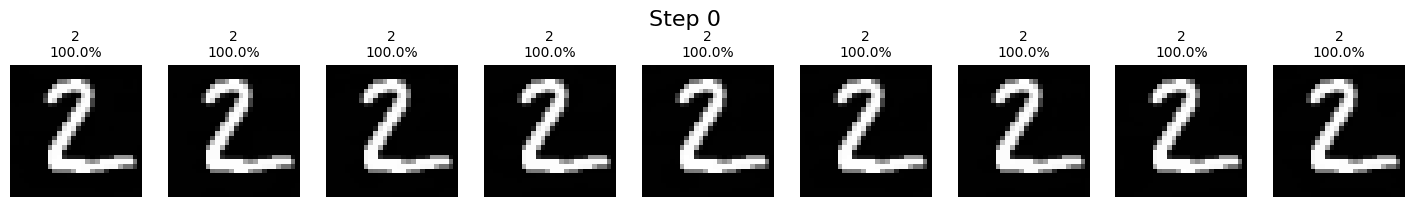

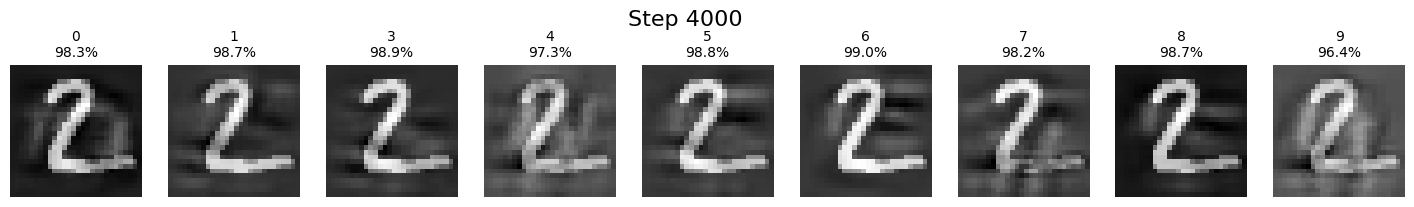

Original label: 2, L2 penalty: 4.642


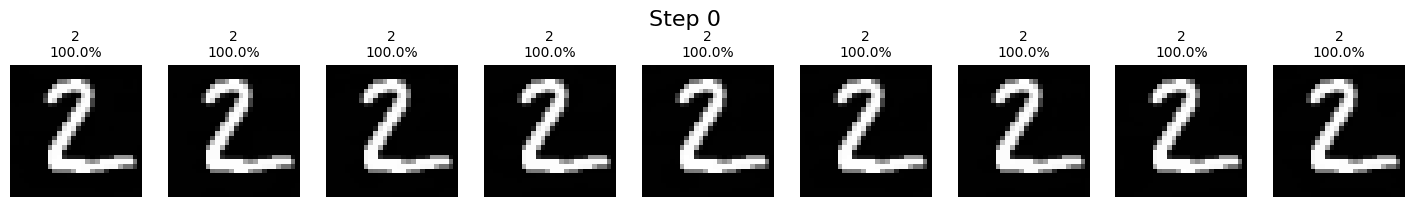

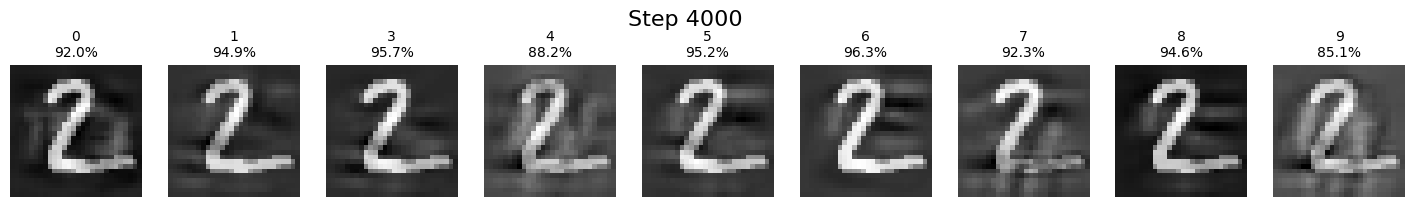

Original label: 2, L2 penalty: 21.54


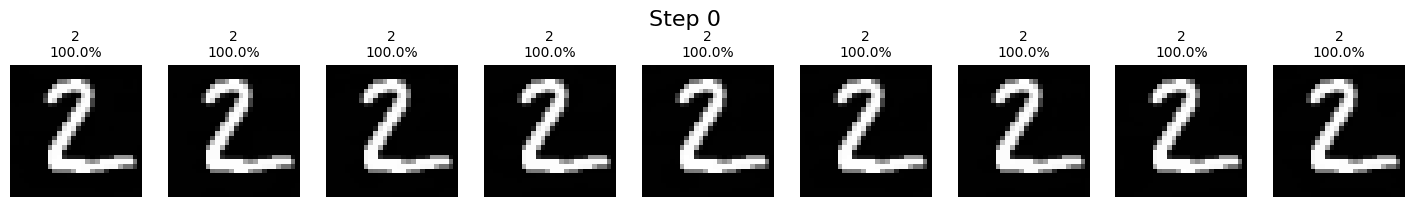

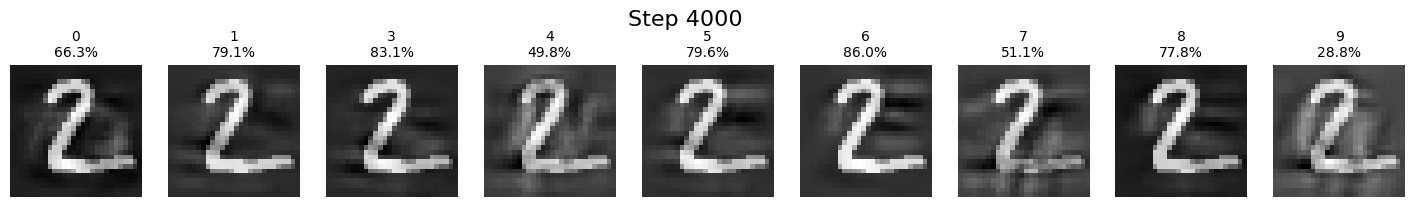

Original label: 2, L2 penalty: 100.0


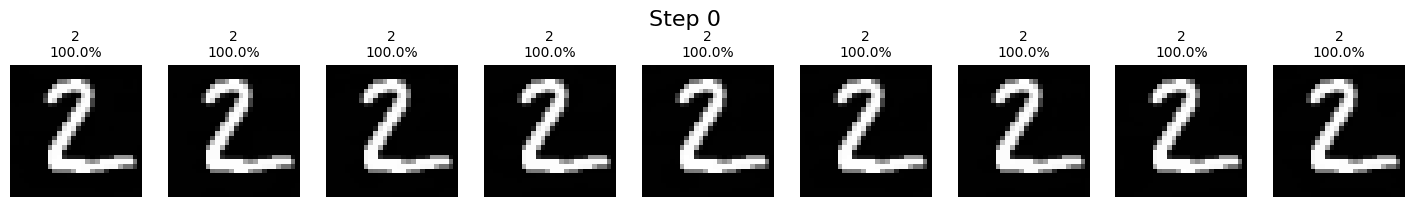

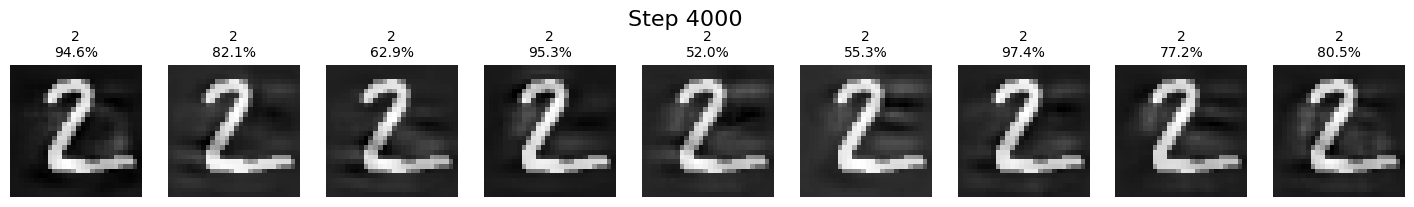

In [ ]:
def proceed_task2(image_number, penalties, dataset, net):

    # We do not want to change the parameters of the net, so we set it to eval() mode ang turn off 'requires_grad' parameters
    net.eval()
    for p in net.parameters():
        p.requires_grad = False

    # Load the image and print its true label
    image, label = dataset[image_number]
    flase_labels = torch.arange(0, 10, device=device)   # (10)
    flase_labels = flase_labels[flase_labels != label]  # (9)
    image = image.to(device=device)                     # (1, 28, 28)

    #move data to device
    flase_labels = flase_labels.to(device=device)
    image = image.unsqueeze(0).to(device)        # (1,1,28,28)

    """
    plot_original = image[0, 0].detach().cpu().clone()
    plt.imshow(plot_original, cmap="gray")
    plt.title(f"Original image")
    plt.show()
    """

    for lambda_l2 in penalties:

        # Add the noise and optimize it with chosen L2 penalty
        noise = torch.zeros(size=(flase_labels.shape[0], *image.shape[-3:]), device=device, requires_grad=True)  # (9,1,28,28)
        optimizer = torch.optim.Adam([noise], lr=0.01)

        print(f"Original label: {label}, L2 penalty: {lambda_l2:.4}")

        for step in range(4001):
            out = net(image + noise)                 # (9,10)
            loss = F.cross_entropy(out, flase_labels) + lambda_l2 * noise.pow(2).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if step % 4000 == 0:
                    plot_images = (image+noise).detach().cpu().clone()
                    plot_logits = out.detach().cpu().clone()
                    show_dreams(plot_images, plot_logits, step)


penalties = np.geomspace(1e-4, 100, 10)

# Experiment with different lambda_l2 values for a given image
proceed_task2(image_number=1, penalties=penalties, dataset=testset, net=net)

W eksperymencie z zadania 2 analizujemy, w jaki sposób sieć LeNet‑5 reaguje na celowo konstruowane, subtelne zaburzenia wejścia, których zadaniem jest doprowadzenie do błędnej klasyfikacji przy jednoczesnym zachowaniu wizualnej postaci oryginalnej cyfry. Dla bardzo małych wartości parametru regularyzacji $\lambda$ obserwujemy, że proces optymalizacji może przez długi czas dokładać do obrazu dodatkowe tło, którechociaż dla człowieka zauważalne, to nie wpływa na percepcję cyfry, natomiast dla sieci staje się dominującym sygnałem prowadzącym do klasyfikacji zgodnej z zadanym celem ataku. W tym zakresie $\lambda$ sieć daje się stosunkowo łatwo oszukać, ponieważ nawet niewielkie, ale odpowiednio ukierunkowane fluktuacje pikseli mogą silnie aktywować konkretne filtry konwolucyjne, co skutkuje wysoką pewnością błędnej predykcji.

Sytuacja zaczyna się zmieniać dopiero wtedy, gdy $\lambda$ osiąga wartości rzędu kilkudziesięciu. W tym obszarze kara za dodawanie szumu staje się na tyle istotna, że optymalizacja nie jest już w stanie wygenerować wystarczająco silnego „tła”, które mogłoby przechylić decyzję sieci na korzyść klasy docelowej. W rezultacie poziom perturbacji pozostaje zbyt niski, aby sieć mogła go wykorzystać jako sygnał prowadzący do błędnej klasyfikacji. Dla największych wartości $\lambda$, zbliżających się do 100, ataki przestają być skuteczne: sieć konsekwentnie pozostaje przy klasyfikacji zgodnej z oryginalną etykietą, choć zauważalnie spada jej pewność predykcji. Oznacza to, że silna regularyzacja skutecznie tłumi wszelkie niejednorodności wprowadzane przez optymalizację, uniemożliwiając modelowi „zaczepienie się” o dodatkowe struktury w tle, które w niższych zakresach $\lambda$ były głównym nośnikiem błędnej klasyfikacji.

### Success rates of missclasification for different $\lambda$ values

In [ ]:
# config
num_images = 100            #number of images to process
lambdas = [1.0, 5.0, 10.0, 20.0, 35.0, 45.0, 60.0, 75.0, 90.0, 100.0]       #lambda values to check

successes = {lam: 0 for lam in lambdas}
attempts = {lam: 0 for lam in lambdas}

net.eval()
for p in net.parameters():
    p.requires_grad = False

# batch of images
images = []
labels = []

for idx in range(num_images):
    img, lab = testset[idx]
    images.append(img.unsqueeze(0))   # (1, 1, 28, 28)
    labels.append(lab)

images = torch.cat(images, dim=0).to(device)   # (num_images, 1, 28, 28)
labels = torch.tensor(labels, device=device)   # (num_images,)

# target false labels
false_labels = []
for lab in labels:
    fl = torch.arange(10, device=device)
    fl = fl[fl != lab]     # (9,)
    false_labels.append(fl)

false_labels = torch.stack(false_labels, dim=0)   # (num_images, 9)

images_expanded = images.unsqueeze(1).repeat(1, 9, 1, 1, 1)
images_expanded = images_expanded.reshape(-1, 1, 28, 28)   # (num_images*9,1,28,28)

# reshape target false labels
targets_expanded = false_labels.reshape(-1)   # (num_images*9,)

for lam in lambdas:
    # noise: num_images x 9
    noise = torch.zeros_like(images_expanded, requires_grad=True)
    optimizer = torch.optim.Adam([noise], lr=0.02)

    for step in range(800):   # 800 optimization steps
        out = net(images_expanded + noise)   # (num_images*9, 10)

        loss = F.cross_entropy(out, targets_expanded) + lam * noise.pow(2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # results
    final_preds = out.argmax(dim=1)
    attempts[lam] += targets_expanded.numel()
    successes[lam] += (final_preds == targets_expanded).sum().item()

    print(f"lambda={lam}: success rate = {successes[lam] / attempts[lam]:.4f}")


lambda=1.0: success rate = 1.0000
lambda=5.0: success rate = 1.0000
lambda=10.0: success rate = 1.0000
lambda=20.0: success rate = 1.0000
lambda=35.0: success rate = 0.9622
lambda=45.0: success rate = 0.8800
lambda=60.0: success rate = 0.7300
lambda=75.0: success rate = 0.5700
lambda=90.0: success rate = 0.4233
lambda=100.0: success rate = 0.3478


Analiza success rate dla różnych wartości parametru regularyzacji $\lambda$ pokazuje bardzo wyraźny i systematyczny wpływ siły kary $L_2$ na skuteczność ataków adversarialnych. W zakresie niskich i umiarkowanych wartości λ (od 1 do około 20) ataki są praktycznie w pełni skuteczne, a success rate utrzymuje się na poziomie 100%. Oznacza to, że nawet przy umiarkowanej regularyzacji optymalizacja wciąż jest w stanie wygenerować takie perturbacje, które pozostają wizualnie subtelne, a jednocześnie skutecznie „przekonują” sieć do błędnej klasyfikacji. W tym obszarze model nadal łatwo daje się oszukać, ponieważ kara $L_2$ nie ogranicza jeszcze istotnie swobody optymalizacji.

Dopiero po przekroczeniu wartości $\lambda \approx 30 - 40$ skuteczność zaczyna stopniowo spadać. Dla $\lambda = 35$ success rate wynosi już ok. 96%, a przy $\lambda = 45$ spada do 88%. Wraz ze wzrostem $\lambda$ perturbacje stają się coraz słabsze i gładsze, co ogranicza możliwość tworzenia charakterystycznych wzorców w tle, które wcześniej były głównym nośnikiem błędnej klasyfikacji. Wysokie wartości $\lambda$ wymuszają bardzo silną regularność obrazu, przez co optymalizacja nie jest już w stanie wygenerować wystarczająco wyraźnego sygnału, który mógłby aktywować odpowiednie filtry konwolucyjne i przechylić decyzję sieci na korzyść klasy docelowej.

W najwyższym zakresie $\lambda$ (60–100) spadek skuteczności staje się bardzo wyraźny: success rate obniża się kolejno do 73%, 57%, 42% i ostatecznie 35% przy $\lambda = 100$. W tym reżimie regularyzacja jest już na tyle silna, że praktycznie uniemożliwia modelowi „wyrysowanie” jakichkolwiek struktur odróżniających klasę docelową od oryginalnej. Sieć zaczyna więc wracać do poprawnej klasyfikacji, choć jej pewność jest zauważalnie niższa niż w przypadku czystych obrazów, co sugeruje, że perturbacje nadal wpływają na aktywacje, ale nie na tyle, by wymusić pełną misklasyfikację.

Warto podkreślić, że w tej serii eksperymentów zastosowano dwukrotnie większy learning rate (0.02 zamiast 0.01), a jednocześnie zmniejszono liczbę kroków optymalizacji z 4000 do 800, aby skrócić czas obliczeń. Oznacza to, że dla bardzo dużych wartości $\lambda$ success rate mógłby być nieco wyższy, gdyby pozwolić optymalizacji na dłuższą pracę. Nie zmienia to jednak ogólnego obrazu: im silniejsza regularyzacja, tym trudniej wygenerować skuteczną perturbację, a granica, przy której ataki przestają działać, wypada właśnie w okolicach $\lambda \approx 50 - 100$.